# 1-D TEM Inversion Notebook

This notebook builds a synthetic central-loop TEM dataset, computes a 1-D Jacobian, runs a regularised Gauss-Newton inversion, and estimates DOI from reference-model dependence.

| Symbol | Meaning |
|--------|---------|
| $\mathbf{d}$ | Observed data vector |
| $\mathbf{m}$ | Model vector, $\ln\rho$ |
| $F(\mathbf{m})$ | Forward response |
| $\mathbf{J}$ | Jacobian |
| $\mathbf{W}_d$ | Data weights |
| $\mathbf{R}$ | Roughness matrix |
| $\alpha$ | Regularisation weight |

In [46]:
import sys
import time
import importlib

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, r'C:\Users\pamcl\OneDrive - Danmarks Tekniske Universitet\Dokumenter\Projects\Python\pyTEM')

import pytem
importlib.reload(pytem.recursion)
importlib.reload(pytem)

from pytem import (
    tem_forward_circle,
    dbdt_to_apprho,
    MU0,
    HAS_NUMBA,
    HAS_CUDA,
    HANKEL_FILTERS,
    FOURIER_FILTERS,
)

print(f"Numba: {HAS_NUMBA}, CUDA: {HAS_CUDA}")

Numba: True, CUDA: True


In [47]:
times = np.logspace(-5, -2, 31)
loop_side = 50.0
L = loop_side
a = np.sqrt((L**2) / np.pi)

depths0 = np.array([0.0, 5.0, 10.0, 20.0, 30.0, 45.0, 100.0])
thicknesses0 = np.diff(depths0)

z = depths0[:-1]
z_norm = (z - z.min()) / (z.max() - z.min())

base_trend = 180 - 80 * z_norm
undulation = 50 * np.sin(2 * np.pi * 1.2 * z_norm)
shallow_high = 10 * np.exp(-0.5 * ((z_norm - 0.18) / 0.10) ** 2)
mid_low = -50 * np.exp(-0.5 * ((z_norm - 0.60) / 0.12) ** 2)
deep_high = 10 * np.exp(-0.5 * ((z_norm - 0.88) / 0.08) ** 2)
rho0 = base_trend + undulation + shallow_high + mid_low + deep_high

rel_noise = 0.02
noise_at_1ms = 1e-10

obs_data = tem_forward_circle(
    thicknesses=thicknesses0,
    resistivities=rho0,
    tx_radius=a,
    times=times,
    use_numba=False,
)

noise_floor = noise_at_1ms * (times / 1e-3) ** (-0.5)
noise_std = np.sqrt((rel_noise * np.abs(obs_data)) ** 2 + noise_floor ** 2)
obs_data += np.random.normal(size=obs_data.shape) * noise_std

## 2. Inverse Theory

We solve for the log-resistivity model $\mathbf{m}$ by minimising a data-fit term plus a smoothness term:

$$\Phi = \Phi_d + \alpha\,\Phi_m$$

$$\Phi_d = \|\mathbf{W}_d(\mathbf{d} - F(\mathbf{m}))\|_2^2, \qquad \Phi_m = \mathbf{m}^T \mathbf{R}\,\mathbf{m}$$

$\mathbf{J}$ measures how each gate responds to each layer, and $\mathbf{R}$ penalises sharp layer-to-layer changes.

In [36]:
def getRMS(obs_data, mod_data, obs_noise):
    """Root-mean-square misfit normalised by noise."""
    total_points = obs_data.size
    data_residual = (mod_data - obs_data) ** 2 / (obs_noise) ** 2
    rms = np.sqrt(np.sum(data_residual) / total_points)
    return rms


def getAlpha(alpha_start, step):
    """Log-spaced regularisation parameter for a given cooling step."""
    alpha_step = 1 / 9
    log_alpha = np.log10(alpha_start) - alpha_step * step
    alpha = 10 ** log_alpha
    return alpha


def getAlphas(alpha, thicknesses):
    """Depth-weighted regularisation vector."""
    thicknesses = np.asarray(thicknesses)
    tops = np.cumsum(np.concatenate(([0], thicknesses[:-1])))
    midpoints = tops + thicknesses / 2.0
    del_z = np.diff(midpoints)
    alpha_factor = np.empty(len(del_z) + 1, dtype=del_z.dtype)
    alpha_factor[0] = 1 / del_z[0]
    alpha_factor[1:-1] = 1 / del_z[:-1] + 1 / del_z[1:]
    alpha_factor[-1] = 1 / del_z[-1]
    return alpha * alpha_factor


def getR(resistivities, damp=1e-4):
    """First-order roughness (smoothness) matrix with optional damping."""
    n_params = resistivities.size
    D = np.zeros((n_params - 1, n_params))
    for k in range(n_params - 1):
        D[k, k] = -1.0
        D[k, k + 1] = 1.0
    R = D.T @ D + damp * np.eye(n_params)
    return R


def getJ(thicknesses, log_resistivities, tx_geom, times,
         use_numba=False, use_cuda=True, eps=1e-4, fwd=tem_forward_circle,
         transform='dlf', hankel_filter='key_201', fourier_filter='key_81',
         euler_order=11):
    """Finite-difference Jacobian d(log(-dBdt))/d(ln rho)."""

    f0 = -fwd(
        thicknesses=thicknesses,
        resistivities=np.exp(log_resistivities),
        tx_radius=tx_geom,
        times=times,
        use_numba=use_numba,
        use_cuda=use_cuda,
        transform=transform,
        hankel_filter=hankel_filter,
        fourier_filter=fourier_filter,
        euler_order=euler_order,
    )

    bad_f0 = f0 <= 0
    if np.any(bad_f0):
        print(f"WARNING: f0 has {bad_f0.sum()} non-positive values at gate indices {np.where(bad_f0)[0]} (zeroed in J)")

    J = np.zeros((f0.size, log_resistivities.size))
    bad_count = 0
    for i in range(log_resistivities.size):
        perturbed = log_resistivities.copy()
        step = eps * max(1.0, abs(log_resistivities[i]))
        perturbed[i] += step

        fi = -fwd(
            thicknesses=thicknesses,
            resistivities=np.exp(perturbed),
            tx_radius=tx_geom,
            times=times,
            use_numba=use_numba,
            use_cuda=use_cuda,
            transform=transform,
            hankel_filter=hankel_filter,
            fourier_filter=fourier_filter,
            euler_order=euler_order,
        )

        valid = (f0 > 0) & (fi > 0)
        if not np.all(valid):
            bad_count += 1
        J[valid, i] = (np.log(fi[valid]) - np.log(f0[valid])) / step

    if bad_count:
        print(f"WARNING: {bad_count}/{log_resistivities.size} perturbed models had non-positive values (zeroed in J)")

    return J

## 3. Inversion Mesh

The inversion uses a 1-D layered mesh with a homogeneous starting model in log-resistivity.

In [37]:
depths = np.array([1., 2.088, 3.272, 4.56, 5.962, 7.487, 9.147,
                   10.953, 12.918, 15.056, 17.382, 19.913, 22.667, 
                   25.664, 28.925, 32.473, 36.334, 40.535, 45.106, 
                   50.08 , 55.492, 61.381, 67.789, 74.762, 82.349, 
                   90.604, 99.587, 109.361, 120.001])

thicknesses = np.diff(depths).tolist()
log_resistivities = np.ones_like(thicknesses) * 4.5

In [38]:
J = getJ(thicknesses=thicknesses, log_resistivities=log_resistivities, 
         tx_geom=L, times=times, use_cuda=True, eps=1e-4, fwd=tem_forward_circle,
         transform='dlf', hankel_filter='key_101', fourier_filter='key_101', euler_order=15)

In [39]:
def dbdt_to_apprho(obs_data, tx_area, times):
    """Convert dB/dt to apparent resistivity.

    Parameters
    ----------
    obs_data : array_like
        Observed dB/dt values [T/s].
    tx_area  : float
        Transmitter moment (current × area) [A·m²].
    times    : array_like
        Gate centre times [s].

    Returns
    -------
    rho_a : ndarray
        Apparent resistivity [Ohm·m].
    """
    M = tx_area
    term = (2 * MU0 * M) / (5 * times * obs_data)
    app_rho = (MU0 / (4 * np.pi * times)) * (term ** (2 / 3))
    return app_rho

## 4. Jacobian Check

Before inversion, the finite-difference Jacobian is inspected to confirm the expected depth and gate sensitivity structure.

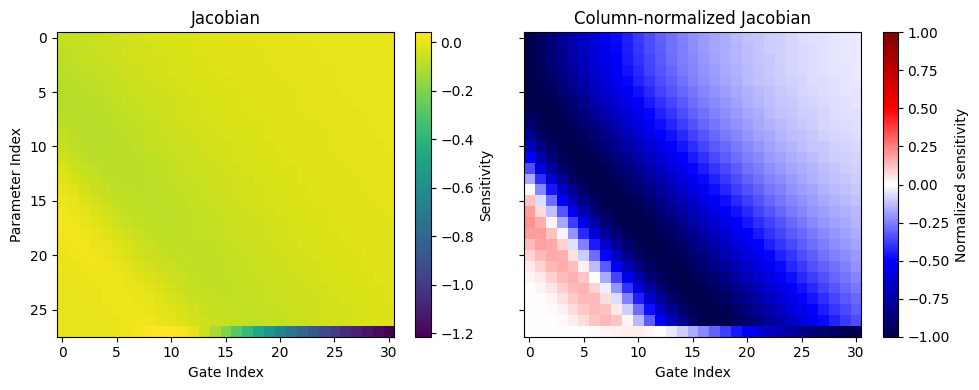

In [40]:
sens_normalized = J / np.abs(J).max(axis=0, keepdims=True)

fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

im0 = axs[0].imshow(J.T, aspect='auto', cmap='viridis')
plt.colorbar(im0, ax=axs[0]).set_label('Sensitivity')
axs[0].set_title('Jacobian')
axs[0].set_ylabel('Parameter Index')
axs[0].set_xlabel('Gate Index')

im1 = axs[1].imshow(sens_normalized.T, aspect='auto', cmap='seismic', vmin=-1, vmax=1)
plt.colorbar(im1, ax=axs[1]).set_label('Normalized sensitivity')
axs[1].set_title('Column-normalized Jacobian')
axs[1].set_xlabel('Gate Index')

fig.tight_layout()

### Sensitivity

The first panel shows the raw Jacobian. The second shows the same matrix after column normalisation, which makes the relative contribution of each layer easier to compare across gates.

### 4a. Analytical Jacobian

An analytical Jacobian can also be obtained by differentiating the layered-earth recursion directly. That gives a faster reference solution than finite differences and is useful for checking the numerical Jacobian.

## 5. Regularised Gauss-Newton Inversion

The inversion is carried out in log space. A reference model is included in the model objective:

$$\Phi_m = \beta\,(\mathbf{m}-\mathbf{m}_{ref})^T \mathbf{R}(\mathbf{m}-\mathbf{m}_{ref})$$

At each iteration, the update balances data fit and smoothness through

$$\left(\mathbf{J}_w^T\mathbf{J}_w + \alpha\beta\mathbf{R}\right)\Delta\mathbf{m} = \mathbf{J}_w^T\mathbf{d}_w - \alpha\beta\mathbf{R}(\mathbf{m}_k-\mathbf{m}_{ref})$$

Here $\beta$ controls how strongly the model is pulled toward the reference. Using $\mathbf{m}_{ref}$ explicitly also makes DOI testing straightforward.

In [53]:
def invert(obs_data, thicknesses, log_resistivities, tx_radius, times, alpha_start=None, alpha_steps=5, maxit=10, eps=1e-4, noise_std=0.02,
           use_numba=False, use_cuda=True, calc_sens=False, store_J=False,
           transform='dlf', hankel_filter='key_101', fourier_filter='key_101', euler_order=11,
           rho_min=1e-1, rho_max=1e5, ref_model=None, ref_weight=1.0):
    """Regularized Gauss-Newton inversion in log-resistivity space.

    The model objective uses a reference model term:
        phi_m = ref_weight * (m - m_ref)^T R (m - m_ref)
    """
    start_time = time.time()

    obs_data_full = np.asarray(obs_data, dtype=float)
    times_full = np.asarray(times, dtype=float)
    if obs_data_full.shape != times_full.shape:
        raise ValueError("obs_data and times must have the same shape")

    print(f"DATA POINTS READ: {obs_data_full.size}")
    valid_obs = obs_data_full > 0
    removed_idx = np.where(~valid_obs)[0]
    print(f"DATA POINTS {removed_idx.size} REMOVED at gate index {removed_idx.tolist()} due to non-positive values")

    if removed_idx.size == obs_data_full.size:
        raise ValueError("All observed data points are non-positive after filtering")

    obs_data = obs_data_full[valid_obs]
    times_inv = times_full[valid_obs]

    if isinstance(noise_std, (int, float)):
        noise_std_inv = float(noise_std)
    else:
        noise_std_full = np.asarray(noise_std, dtype=float)
        if noise_std_full.shape != obs_data_full.shape:
            raise ValueError("noise_std must have same shape as obs_data when array-like")
        noise_std_inv = noise_std_full[valid_obs]

    def _forward_response(log_rho, use_full_times=False):
        forward_times = times_full if use_full_times else times_inv
        return -tem_forward_circle(
            thicknesses=thicknesses,
            resistivities=np.exp(log_rho),
            tx_radius=tx_radius,
            times=forward_times,
            use_numba=use_numba,
            use_cuda=use_cuda,
            transform=transform,
            hankel_filter=hankel_filter,
            fourier_filter=fourier_filter,
            euler_order=euler_order,
        )

    app_res = np.mean(dbdt_to_apprho(obs_data, np.pi * tx_radius**2, times_inv))

    m = np.asarray(log_resistivities, dtype=float).copy()
    m_ref = m.copy() if ref_model is None else np.asarray(ref_model, dtype=float)
    if m_ref.shape != m.shape:
        raise ValueError("ref_model must have same shape as log_resistivities")

    R = getR(m)
    R_ref = ref_weight * R

    print(f"DATA POINTS USED: {obs_data.size}")
    print(f"REFERENCE MODEL WEIGHT: {ref_weight:.2f}")

    # Data weights w = 1/sigma in log space
    if isinstance(noise_std_inv, float):
        sigma_log = np.full(obs_data.size, noise_std_inv)
        print(f"MEAN LATE-TIME APPARENT RESISTIVITY: {app_res:.2f} Ohm.m, NOISE: {noise_std_inv*100:.2f}%")
    else:
        sigma_log = noise_std_inv / np.abs(obs_data)
        print(
            "MEAN LATE-TIME APPARENT RESISTIVITY: "
            f"{app_res:.2f} Ohm.m, NOISE STD: min={noise_std_inv.min():.2e}, max={noise_std_inv.max():.2e}"
        )
    w = 1.0 / sigma_log

    alpha_unit = getAlphas(1.0, thicknesses)
    R_alpha = np.diag(alpha_unit) @ R_ref

    ln_rho_min = np.log(rho_min)
    ln_rho_max = np.log(rho_max)

    iter_rms_list = []
    iter_roughness_list = []
    rho_hist = []
    if store_J:
        J_hist = []

    print("\nSTARTING INVERSION...")

    for it in range(maxit):
        print(f"\nITERATION {it + 1}")

        mod_data = _forward_response(m, use_full_times=False)
        d = np.log(obs_data) - np.log(mod_data)

        rms = np.sqrt(np.mean((w * d) ** 2))
        dm_ref = m - m_ref
        phi_m = dm_ref @ R_ref @ dm_ref
        print(f"    Initial Data Misfit: {rms:.4f},  Model Misfit: {phi_m:.4f}")

        J = getJ(
            thicknesses=thicknesses,
            log_resistivities=m,
            tx_geom=tx_radius,
            times=times_inv,
            use_numba=use_numba,
            use_cuda=use_cuda,
            eps=1e-4,
            fwd=tem_forward_circle,
            transform=transform,
            hankel_filter=hankel_filter,
            fourier_filter=fourier_filter,
            euler_order=euler_order,
        )

        if store_J:
            J_hist.append(J.copy())

        Jw = w[:, None] * J
        dw = w * d

        if it == 0 and alpha_start is None:
            JtJ = Jw.T @ Jw
            alpha_start = np.trace(JtJ) / np.trace(R_alpha)
            print(f"    No alpha specified, using: {alpha_start:.2f}")

        alpha_hist = []
        rms_hist = []
        delta_hist = []

        if it != 0:
            alpha_start = alpha_new

        for i in range(alpha_steps):
            alpha_temp = getAlpha(alpha_start, step=i)

            alpha_vector = getAlphas(alpha_temp, thicknesses)
            alpha_matrix = np.diag(alpha_vector)

            lhs = Jw.T @ Jw + alpha_matrix @ R_ref
            rhs = Jw.T @ dw - alpha_matrix @ (R_ref @ (m - m_ref))

            delta = np.linalg.solve(lhs, rhs)

            step = 1.0
            for _ in range(10):
                trial = m + step * delta
                if np.all(trial >= ln_rho_min) and np.all(trial <= ln_rho_max):
                    break
                step *= 0.5
            else:
                trial = np.clip(m + step * delta, ln_rho_min, ln_rho_max)

            delta_hist.append(trial - m)

            mod_data_trial = _forward_response(trial, use_full_times=False)
            d_trial = np.log(obs_data) - np.log(mod_data_trial)
            rms_trial = np.sqrt(np.mean((w * d_trial) ** 2))

            print(
                f"    Alpha: {alpha_temp:.2f}, Data Misfit: {rms_trial:.4f}"
                + (f" (step={step:.2f})" if step < 1.0 else "")
            )
            alpha_hist.append(alpha_temp)
            rms_hist.append(rms_trial)

            if len(rms_hist) > 2 and rms_hist[-1] > np.min(rms_hist[:-1]):
                break

        best_idx = np.argmin(rms_hist)
        print(f"    Best Data Misfit: {rms_hist[best_idx]:.4f}")

        iter_rms_list.append(rms_hist[best_idx])

        m = m + delta_hist[best_idx]
        resistivities = np.exp(m)
        rho_hist.append(resistivities.copy())

        dm_ref = m - m_ref
        phi_m = dm_ref @ R_ref @ dm_ref
        iter_roughness_list.append(phi_m)

        alpha_best = alpha_hist[best_idx]
        chi = max(iter_rms_list[-1], 1.01)
        alpha_decay = np.log10(0.588) / np.log10(chi)
        alpha_new = alpha_best * 0.5 * chi ** (-alpha_decay)

        if it >= 2:
            recent_rms = iter_rms_list[-3:]
            if np.std(recent_rms) < eps * np.mean(recent_rms):
                print("\nCONVERGENCE ACHIEVED BASED ON chi STABILITY.")
                break

    best_rho = rho_hist[np.argmin(iter_rms_list)]
    best_rms = np.min(iter_rms_list)

    mod_data = _forward_response(np.log(best_rho), use_full_times=True)

    print(f"\nTOTAL INVERSION TIME: {(time.time() - start_time):.2f} seconds")
    print(f"FINAL DATA MISFIT: {best_rms:.3f}")

    if store_J:
        return best_rho, mod_data, iter_rms_list, iter_roughness_list, rho_hist, J_hist

    if calc_sens:
        print("CALCULATING SENSITIVITY MATRIX FOR FINAL MODEL...")
        J = getJ(
            thicknesses=thicknesses,
            log_resistivities=np.log(best_rho),
            tx_geom=tx_radius,
            times=times_inv,
            use_numba=use_numba,
            use_cuda=use_cuda,
            eps=1e-4,
            fwd=tem_forward_circle,
            transform=transform,
            hankel_filter=hankel_filter,
            fourier_filter=fourier_filter,
            euler_order=euler_order,
        )
        return best_rho, mod_data, iter_rms_list, iter_roughness_list, rho_hist, J

    return best_rho, mod_data, iter_rms_list, iter_roughness_list, rho_hist

### Run Inversion

Start from a homogeneous half-space and iterate until the RMS stabilises.

In [49]:
log_resistivities = np.ones_like(thicknesses) * np.log(20.0)

best_rho, mod_data, iter_rms_list, iter_roughness_list, rho_hist = invert(
    obs_data=-obs_data,
    thicknesses=thicknesses,
    log_resistivities=log_resistivities,
    tx_radius=a,
    times=times,
    alpha_steps=10,
    maxit=30,
    eps=1e-4,
    noise_std=noise_std,
    use_cuda=True,
    calc_sens=False,
    transform='dlf',
    hankel_filter='key_101',
    fourier_filter='key_101',
)

DATA POINTS READ: 31
DATA POINTS 2 REMOVED at gate index [26, 28] due to non-positive values
DATA POINTS USED: 29
MEAN LATE-TIME APPARENT RESISTIVITY: 108.76 Ohm.m, NOISE STD: min=3.16e-11, max=1.15e-06

STARTING INVERSION...

ITERATION 1
    Initial Data Misfit: 88.4265,  Model Misfit: 0.0000
    No alpha specified, using: 133.80
    Alpha: 133.80, Data Misfit: 23.4192
    Alpha: 103.60, Data Misfit: 24.6375
    Alpha: 80.21, Data Misfit: 25.8637
    Best Data Misfit: 23.4192

ITERATION 2
    Initial Data Misfit: 23.4192,  Model Misfit: 2.3176
    Alpha: 113.77, Data Misfit: 56.7372
    Alpha: 88.09, Data Misfit: 58.6095
    Alpha: 68.21, Data Misfit: 60.2019
    Best Data Misfit: 56.7372

ITERATION 3
    Initial Data Misfit: 56.7372,  Model Misfit: 3.7958
    Alpha: 96.75, Data Misfit: 47.4120
    Alpha: 74.91, Data Misfit: 48.0373
    Alpha: 58.00, Data Misfit: 48.7053
    Best Data Misfit: 47.4120

ITERATION 4
    Initial Data Misfit: 47.4120,  Model Misfit: 1.9166
    Alpha: 82.27

## 6. Results

Summary plots: data fit, RMS history, and recovered resistivity model.

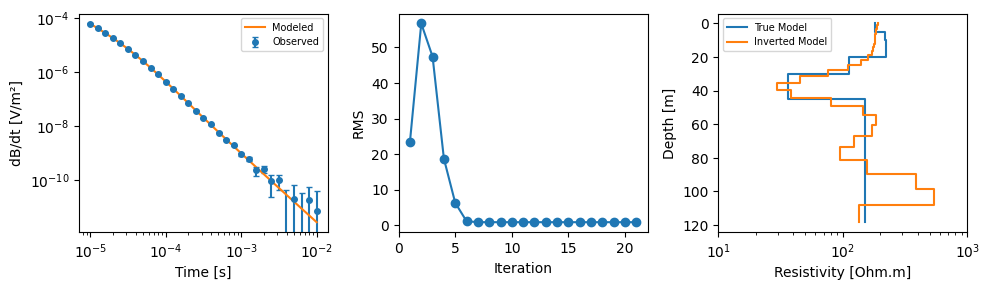

In [50]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3))

axs[0].errorbar(times, -obs_data, yerr=noise_std, fmt='o', markersize=4, capsize=2, label='Observed')
axs[0].loglog(times, mod_data, '-', label='Modeled', markersize=4)
axs[0].set_xlabel('Time [s]')
axs[0].set_ylabel('dB/dt [V/m²]')
axs[0].legend(fontsize=7)

axs[1].plot(range(1, len(iter_rms_list) + 1), iter_rms_list, 'o-')
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel('RMS')

depths0 = np.cumsum(np.concatenate(([0], thicknesses0[:-1])))
axs[2].step(np.r_[rho0, rho0[-1]], np.r_[depths0, depths[-1]+10], where='pre', label='True Model')
depths = np.cumsum(np.concatenate(([0], thicknesses[:-1])))
axs[2].step(np.r_[best_rho, best_rho[-1]], np.r_[depths, depths[-1]+10], where='pre', label='Inverted Model')

axs[2].invert_yaxis()
axs[2].set_xlabel('Resistivity [Ohm.m]')
axs[2].set_ylabel('Depth [m]')
axs[2].set_xscale('log')
axs[2].legend(fontsize=7)
axs[2].set_xlim(10, 1000)

fig.tight_layout()

## 7. Li-Oldenburg DOI

The DOI test runs the same inversion with two different reference models and compares the recovered results.

$$\mathrm{DOI}_j = \frac{|m_j^{(1)} - m_j^{(2)}|}{|m_{ref,j}^{(1)} - m_{ref,j}^{(2)}|}$$

with $m = \ln\rho$. Small values mean the layer is mainly data-controlled; large values mean it is more reference-controlled.

DATA POINTS READ: 31
DATA POINTS 2 REMOVED at gate index [26, 28] due to non-positive values
DATA POINTS USED: 29
REFERENCE MODEL WEIGHT: 20.00
MEAN LATE-TIME APPARENT RESISTIVITY: 108.76 Ohm.m, NOISE STD: min=3.16e-11, max=1.15e-06

STARTING INVERSION...

ITERATION 1
    Initial Data Misfit: 88.4265,  Model Misfit: 0.0000
    No alpha specified, using: 6.69
    Alpha: 6.69, Data Misfit: 23.4192
    Alpha: 5.18, Data Misfit: 24.6375
    Alpha: 4.01, Data Misfit: 25.8637
    Best Data Misfit: 23.4192

ITERATION 2
    Initial Data Misfit: 23.4192,  Model Misfit: 46.3516
    Alpha: 5.69, Data Misfit: 56.7372
    Alpha: 4.40, Data Misfit: 58.6095
    Alpha: 3.41, Data Misfit: 60.2019
    Best Data Misfit: 56.7372

ITERATION 3
    Initial Data Misfit: 56.7372,  Model Misfit: 75.9154
    Alpha: 4.84, Data Misfit: 47.4120
    Alpha: 3.75, Data Misfit: 48.0373
    Alpha: 2.90, Data Misfit: 48.7053
    Best Data Misfit: 47.4120

ITERATION 4
    Initial Data Misfit: 47.4120,  Model Misfit: 38.33

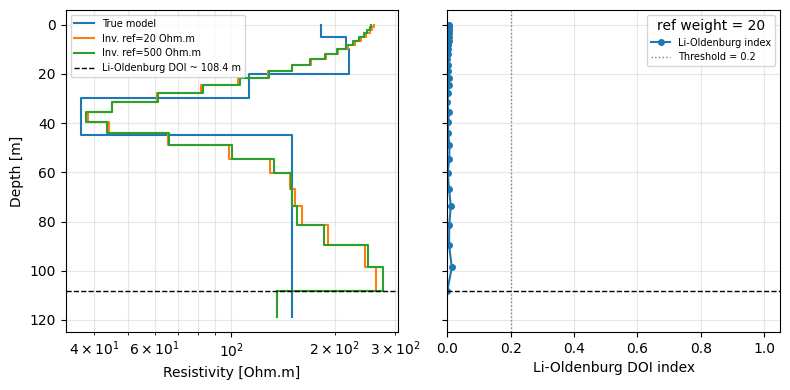

In [57]:
def li_oldenburg_doi_1d(model_1, model_2, ref_1, ref_2, thicknesses, doi_threshold=0.2):
    """Compute 1D Li-Oldenburg DOI index and a representative DOI depth."""
    model_1 = np.asarray(model_1, dtype=float)
    model_2 = np.asarray(model_2, dtype=float)
    ref_1 = np.asarray(ref_1, dtype=float)
    ref_2 = np.asarray(ref_2, dtype=float)
    thicknesses = np.asarray(thicknesses, dtype=float)

    if not (model_1.shape == model_2.shape == ref_1.shape == ref_2.shape):
        raise ValueError("Model and reference arrays must have identical shape")

    denom = np.maximum(np.abs(ref_1 - ref_2), 1e-12)
    doi_idx = np.clip(np.abs(model_1 - model_2) / denom, 0.0, 1.0)

    layer_tops = np.concatenate(([0.0], np.cumsum(thicknesses[:-1])))
    first_ref_controlled = np.where(doi_idx > doi_threshold)[0]
    doi_depth = layer_tops[first_ref_controlled[0]] if first_ref_controlled.size else layer_tops[-1]

    return doi_idx, layer_tops, doi_depth


# Two contrasting reference models (log-resistivity space)
mref_low = np.full_like(log_resistivities, np.log(20.0))
mref_high = np.full_like(log_resistivities, np.log(500.0))
obs_for_inv = -obs_data
li_ref_weight = 20.0
li_maxit = 12
li_alpha_steps = 8

best_rho_low, *_ = invert(
    obs_data=obs_for_inv,
    thicknesses=thicknesses,
    log_resistivities=mref_low.copy(),
    tx_radius=a,
    times=times,
    alpha_steps=li_alpha_steps,
    maxit=li_maxit,
    eps=1e-4,
    noise_std=noise_std,
    use_cuda=True,
    calc_sens=False,
    transform='dlf',
    hankel_filter='key_101',
    fourier_filter='key_101',
    ref_model=mref_low,
    ref_weight=li_ref_weight,
)

best_rho_high, *_ = invert(
    obs_data=obs_for_inv,
    thicknesses=thicknesses,
    log_resistivities=mref_high.copy(),
    tx_radius=a,
    times=times,
    alpha_steps=li_alpha_steps,
    maxit=li_maxit,
    eps=1e-4,
    noise_std=noise_std,
    use_cuda=True,
    calc_sens=False,
    transform='dlf',
    hankel_filter='key_101',
    fourier_filter='key_101',
    ref_model=mref_high,
    ref_weight=li_ref_weight,
)

# Li-Oldenburg DOI must use recovered models in numerator.
m1 = np.log(best_rho_low)
m2 = np.log(best_rho_high)

doi_idx, layer_tops, doi_depth_li = li_oldenburg_doi_1d(
    m1,
    m2,
    mref_low,
    mref_high,
    thicknesses,
    doi_threshold=0.2,
)

# Plot models and Li-Oldenburg DOI only
fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

true_depths = np.concatenate(([0.0], np.cumsum(thicknesses0[:-1]), [np.sum(thicknesses)]))
inv_depths = np.concatenate(([0.0], np.cumsum(np.asarray(thicknesses)[:-1]), [np.sum(thicknesses)]))

axs[0].step(np.r_[rho0, rho0[-1]], true_depths, where='pre', label='True model', lw=1.5)
axs[0].step(np.r_[best_rho_low, best_rho_low[-1]], inv_depths, where='pre', label='Inv. ref=20 Ohm.m')
axs[0].step(np.r_[best_rho_high, best_rho_high[-1]], inv_depths, where='pre', label='Inv. ref=500 Ohm.m')
axs[0].axhline(doi_depth_li, color='k', ls='--', lw=1.0, label=f'Li-Oldenburg DOI ~ {doi_depth_li:.1f} m')
axs[0].set_xscale('log')
axs[0].invert_yaxis()
axs[0].set_xlabel('Resistivity [Ohm.m]')
axs[0].set_ylabel('Depth [m]')
axs[0].legend(fontsize=7)
axs[0].grid(True, which='both', alpha=0.3)

axs[1].plot(doi_idx, layer_tops, 'o-', ms=4, label='Li-Oldenburg index')
axs[1].axvline(0.2, color='gray', ls=':', lw=1.0, label='Threshold = 0.2')
axs[1].axhline(doi_depth_li, color='k', ls='--', lw=1.0)
axs[1].set_xlim(0, 1.05)
axs[1].set_xlabel('Li-Oldenburg DOI index')
axs[1].legend(fontsize=7, title=f'ref weight = {li_ref_weight:g}')
axs[1].grid(True, alpha=0.3)

fig.tight_layout()
print(f'Li-Oldenburg DOI depth (index > 0.2): {doi_depth_li:.1f} m')

In [ ]:
# Plot models and Li-Oldenburg DOI only
fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

true_depths = np.concatenate(([0.0], np.cumsum(thicknesses0[:-1]), [np.sum(thicknesses)]))
inv_depths = np.concatenate(([0.0], np.cumsum(np.asarray(thicknesses)[:-1]), [np.sum(thicknesses)]))

axs[0].step(np.r_[rho0, rho0[-1]], true_depths, where='pre', label='True model', lw=1.5)
axs[0].step(np.r_[best_rho_low, best_rho_low[-1]], inv_depths, where='pre', label='Inv. ref=20 Ohm.m')
axs[0].step(np.r_[best_rho_high, best_rho_high[-1]], inv_depths, where='pre', label='Inv. ref=500 Ohm.m')
axs[0].axhline(doi_depth_li, color='k', ls='--', lw=1.0, label=f'Li-Oldenburg DOI ~ {doi_depth_li:.1f} m')
axs[0].set_xscale('log')
axs[0].invert_yaxis()
axs[0].set_xlabel('Resistivity [Ohm.m]')
axs[0].set_ylabel('Depth [m]')
axs[0].legend(fontsize=7)
axs[0].grid(True, which='both', alpha=0.3)

axs[1].plot(doi_idx, layer_tops, 'o-', ms=4, label='Li-Oldenburg index')
axs[1].axvline(0.2, color='gray', ls=':', lw=1.0, label='Threshold = 0.2')
axs[1].axhline(doi_depth_li, color='k', ls='--', lw=1.0)
axs[1].set_xlim(0, 1)
axs[1].set_xlabel('Li-Oldenburg DOI index')
axs[1].legend(fontsize=7)
axs[1].grid(True, alpha=0.3)

fig.tight_layout()
print(f'Li-Oldenburg DOI depth (index > 0.2): {doi_depth_li:.1f} m')